In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearnex import patch_sklearn
patch_sklearn()
import os
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier,RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.model_selection import train_test_split
import shap

from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score,classification_report


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [2]:
base_dir = '../'
fibseg_dir = os.path.join(base_dir, 'fiber_segmentation_processed_data')


In [23]:
collagen_tb = pd.read_csv(os.path.join(fibseg_dir,'fiber_object_table.csv'))
collagen_tb.dropna(axis =0, inplace=True)
collagen_tb = collagen_tb[np.isfinite(collagen_tb.alignment_score)]#drop non finite elements
collagen_tb['Leap_ID'] = collagen_tb.fov.str.split('_',n = 1).str[0].str.upper()
biosamples_path = '/home/giuseppe/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response_RCB.csv'
biosamples =pd.read_csv(biosamples_path)
collagen_tb = collagen_tb.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)#add metadata on patient
collagen_tb = collagen_tb[collagen_tb['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE']

In [24]:
X = collagen_tb[['major_axis_length',
       'minor_axis_length', 'orientation', 'area', 'eccentricity',
       'euler_number', 'alignment_score','Leap_ID']].groupby(by = 'Leap_ID').mean()
y = collagen_tb[['Leap_ID','new_Response']].drop_duplicates().set_index('Leap_ID')
y['new_Response'] = y.new_Response.replace('enR','nR')
y = X.merge(y,left_index=True,right_index=True)['new_Response']

In [25]:

le = LabelEncoder()
y = le.fit_transform(y)
le.inverse_transform([0,1])

array(['nR', 'pCR'], dtype=object)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(   X, y, test_size=0.33)

In [27]:
from sklearn.model_selection import LeaveOneOut
param_distributions1 = {
   # 'preprocessor__hashenc__n_features':[4,10,20,100,1000],
    'max_features': [1, 5,10,20,50 ,100,None],
    "max_leaf_nodes": [10, 100, 1000, None],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50, 100],
}
clf = RandomForestClassifier(max_features= 1000,class_weight="balanced")
#regr.fit(X_train, y_train)
search_cv1 = RandomizedSearchCV(
    clf,
    param_distributions=param_distributions1,
    scoring='f1_weighted',
    n_iter=100,
    random_state=0,
    cv = 10,
    n_jobs=-1,
)
search_cv1.fit(X_train, y_train)



/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/gius

RandomizedSearchCV(cv=10,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    max_features=1000),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_features': [1, 5, 10, 20, 50, 100,
                                                         None],
                                        'max_leaf_nodes': [10, 100, 1000, None],
                                        'min_samples_leaf': [1, 2, 5, 10, 20,
                                                             50, 100]},
                   random_state=0, scoring='f1_weighted')

In [8]:
search_cv1.best_params_

{'min_samples_leaf': 100, 'max_leaf_nodes': None, 'max_features': 20}

In [28]:
def format_cv_results(param_distributions,search_cv):
    columns = [f"param_{name}" for name in param_distributions.keys()]
    columns += ["mean_test_score", "std_test_score"]
    cv_results = pd.DataFrame(search_cv.cv_results_)
    #cv_results["mean_test_error"] = -cv_results["mean_test_score"]
    #cv_results["std_test_error"] = cv_results["std_test_score"]
    
    return cv_results[columns].sort_values(by="mean_test_score").iloc[:-10:-1],cv_results
cv_results_filt,cv_results1 = format_cv_results(param_distributions1,search_cv1)
cv_results_filt

,param_max_features,param_max_leaf_nodes,param_min_samples_leaf,mean_test_score,std_test_score
51,1,None,10,0.660000,0.298812
86,1,100,10,0.660000,0.316157
63,1,1000,5,0.626667,0.314395
98,1,10,1,0.613333,0.277769
10,1,100,1,0.600000,0.343835
43,1,100,2,0.600000,0.261194
81,1,10,5,0.593333,0.289751
93,20,100,5,0.583333,0.327702
87,20,1000,1,0.576667,0.316596


In [29]:
y_pred = search_cv1.predict(X_test)
y_score = search_cv1.predict_proba(X_test)[:,1]
aucroc = roc_auc_score(y_test, y_score)
accuracy = accuracy_score(y_test, y_pred)
f1_ = f1_score(y_test, y_pred)
bal_acc_ = balanced_accuracy_score(y_test, y_pred)
mode = 'Test'
pcriterion = 'majority'
metrics = {
        f"{mode} Accuracy {pcriterion}": accuracy,
        f"{mode} AUC {pcriterion}": aucroc,
        f"{mode} F1 Score {pcriterion}": f1_,
        f"{mode} Balanced Accuracy": bal_acc_,
}
pd.Series(metrics)

X does not have valid feature names, but RandomForestClassifier was fitted with feature names
X does not have valid feature names, but RandomForestClassifier was fitted with feature names


Test Accuracy majority    0.650000
Test AUC majority         0.593750
Test F1 Score majority    0.588235
Test Balanced Accuracy    0.645833
dtype: float64

In [11]:
print(classification_report(y_train, search_cv1.predict(X_train)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        25
           1       0.34      1.00      0.51        13

    accuracy                           0.34        38
   macro avg       0.17      0.50      0.25        38
weighted avg       0.12      0.34      0.17        38



X does not have valid feature names, but RandomForestClassifier was fitted with feature names
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [12]:
from sklearn.metrics import f1_score

In [30]:
print(classification_report(y_test, search_cv1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.73      0.67      0.70        12
           1       0.56      0.62      0.59         8

    accuracy                           0.65        20
   macro avg       0.64      0.65      0.64        20
weighted avg       0.66      0.65      0.65        20



X does not have valid feature names, but RandomForestClassifier was fitted with feature names


In [31]:
model = search_cv1.best_estimator_
model.n_classes_

2

In [45]:

explainer = shap.TreeExplainer(model,X_test,feature_names=model.feature_names_in_)
shap_values = explainer(X_test)[:,:,1]#shap values positive class

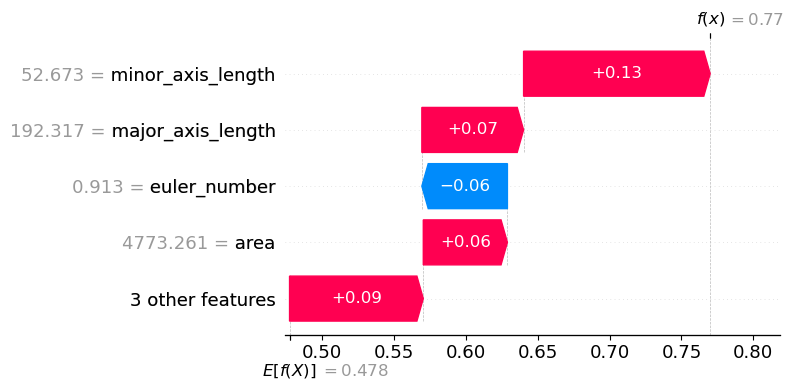

In [47]:
shap.plots.waterfall(shap_values[0], max_display=5,show=False)
plt.tight_layout()
plt.show()
#plt.savefig('figures/shap_waterfall.png')

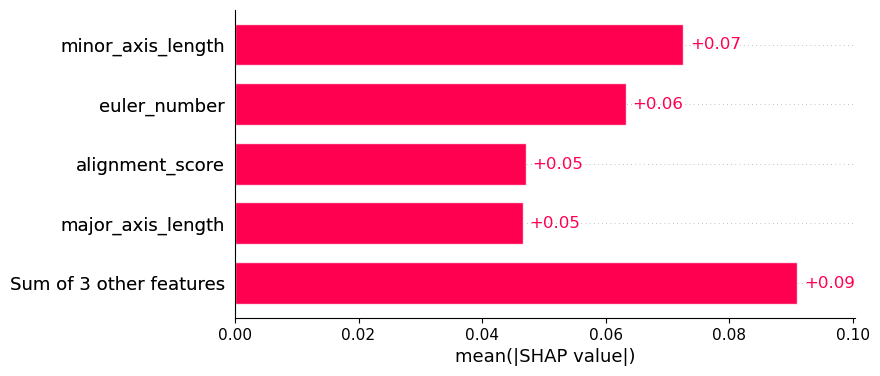

In [50]:
shap.plots.bar(shap_values,max_display=5)

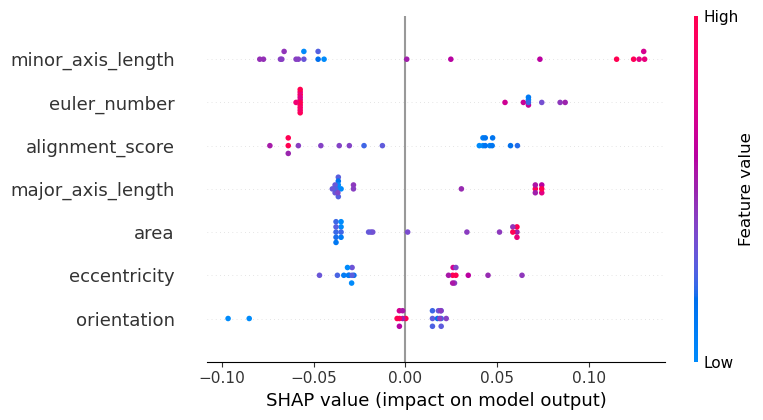

In [53]:

shap.summary_plot(shap_values,show=True)
